<a href="https://colab.research.google.com/github/meganjohnson0522/INFO648/blob/main/Homeworks/Homework_7_INFO_648.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  PART 1


In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('/content/churn_synthetic_600_new.csv')

In [3]:
df.head()

,CustomerID,Churn,TenureMonths,MonthlyCharge,ContractType,PaymentMethod,SupportCalls
0,C0001,1,23,77.81,Month-to-Month,Credit Card,1
1,C0002,0,33,69.65,One-Year,Credit Card,1
2,C0003,1,22,64.27,Month-to-Month,Electronic Check,2
3,C0004,1,4,66.30,Month-to-Month,Credit Card,3
4,C0005,0,2,60.82,One-Year,Bank Transfer,1


In [4]:
df.describe()

,Churn,TenureMonths,MonthlyCharge,SupportCalls
count,600.000000,600.000000,600.000000,600.000000
mean,0.176667,37.270000,71.661650,1.293333
std,0.381705,20.340189,20.113612,1.061052
min,0.000000,1.000000,25.000000,0.000000
25%,0.000000,21.000000,58.147500,0.000000
50%,0.000000,37.000000,71.350000,1.000000
75%,0.000000,54.000000,84.717500,2.000000
max,1.000000,72.000000,134.620000,6.000000


In [5]:
# "TenureMonths", "MonthlyCharge", "SupportCalls", "ContractType", "PaymentMethod"
numeric_features = ["TenureMonths", "MonthlyCharge", "SupportCalls"]
categorical_features = ["ContractType", "PaymentMethod"]

print("Numeric:", numeric_features)
print("Categorical:", categorical_features)

Numeric: ['TenureMonths', 'MonthlyCharge', 'SupportCalls']
Categorical: ['ContractType', 'PaymentMethod']


In [6]:
#Preprocessing Pipeline with one hot encoding

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

Random Forests still require preprocessing because the OneHotEncoder is needed to convert categorical variables into numbers the model can split.

## PART 2

In [7]:
model_df=df.copy()

In [8]:
from sklearn.model_selection import train_test_split
X = model_df[["TenureMonths", "MonthlyCharge", "SupportCalls", "ContractType", "PaymentMethod"]]
y = model_df["Churn"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline([
    ("prep", preprocessor),
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=18, random_state=42))
])

In [11]:
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('prep',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['ContractType',
                                                   'PaymentMethod'])])),
                ('clf',
                 RandomForestClassifier(max_depth=12, min_samples_leaf=18,
                                        n_estimators=300, random_state=42))])

A random forest builds hundreds of trees that are trained from a subset of data and uses a majority for the prediction. This averages the risk of overfitting and prevents one tree from being more important.

##PART 3

In [12]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import confusion_matrix, classification_report

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[124   0]
 [ 25   1]]
              precision    recall  f1-score   support

           0       0.83      1.00      0.91       124
           1       1.00      0.04      0.07        26

    accuracy                           0.83       150
   macro avg       0.92      0.52      0.49       150
weighted avg       0.86      0.83      0.76       150



**Confusion Matrix:**

|  | Predicted: No Churn (0) | Predicted: Churn (1) |
|---|---|---|
| **Actual: No Churn (0)** | 124 | 0 |
| **Actual: Churn (1)** | 25 | 1 |


Accuracy is 0.83 meaning the model correctly labeled 83% of customers overall.

Precision is 1.00 so when the model did not have any false alarms.

Recall is 0.04 so the model only caught 1/26 churners, which is missing almost all of them.

Overall the recall is extremely low and in turn concerning since they are missing about 25/26 churners. The precision is also misleading because you can see in the confusion matrix that the model only predicted any churn for 150 test cases, this means the .50 threshold is most likely not a good measure.

## PART 4

In [14]:
from sklearn.metrics import roc_auc_score

roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])

np.float64(0.8228908188585609)

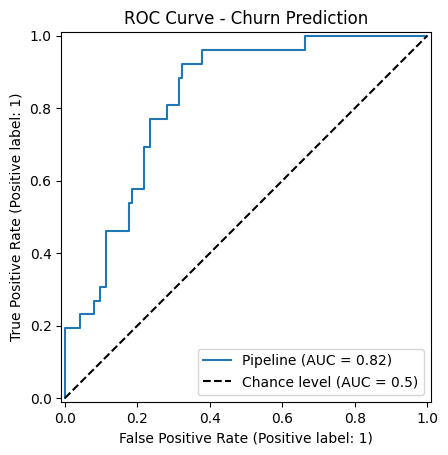

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test, plot_chance_level=True)
plt.title('ROC Curve - Churn Prediction')
plt.show()

1. What does the ROC curve represent in a classification model?
  
    A ROC curve shows TPR against FPR for every threshold.

2. What does the Area Under the Curve (AUC) measure?
  
    It shows the models ability to predict a random churner higher than a non churner seperate from the given threshold.

3. What does the AUC for this model tell us??
  
    This model has a roc score of .82 which means there is a 82% chance the model predicts a churner higher than a non churner. This is better than when we used a decsion tree model.

4. What would an AUC value close to 1.00 imply?
  
    A 1 AUC would mean the model is perfectly splitting the churners from non churners.

5. Why is ROC analysis useful when classification thresholds can change?
  
    Roc analysis is good because the standard 0.5 is not always best and a Roc curve lets us see the performance for different thresholds.

##PART 5

                               Feature  Importance
6              remainder__TenureMonths    0.392141
7             remainder__MonthlyCharge    0.324208
8              remainder__SupportCalls    0.105461
0     cat__ContractType_Month-to-Month    0.078198
4       cat__PaymentMethod_Credit Card    0.033385
5  cat__PaymentMethod_Electronic Check    0.023172
2           cat__ContractType_Two-Year    0.022735
1           cat__ContractType_One-Year    0.011412
3     cat__PaymentMethod_Bank Transfer    0.009288


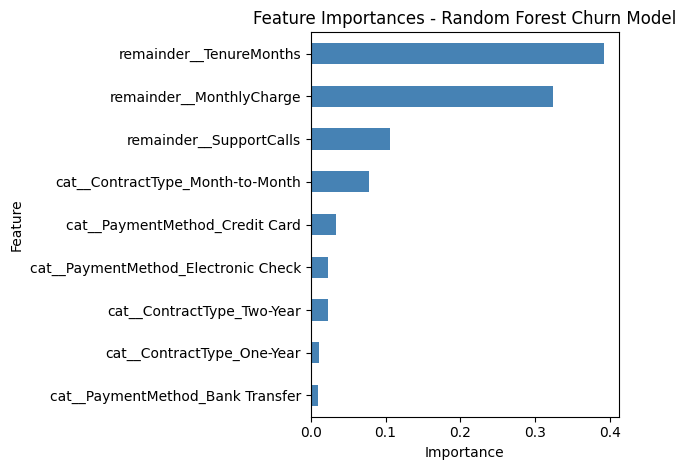

In [18]:
# Part 5 - Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after one-hot encoding
feature_names = model.named_steps['prep'].get_feature_names_out()

# Extract feature importances from the Random Forest
importances = model.named_steps['clf'].feature_importances_

# Create a ranked dataframe
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

# Plot sorted bar chart
feature_importance_df.sort_values(by='Importance').plot(
    kind='barh', x='Feature', y='Importance', legend=False, color='steelblue'
)
plt.title('Feature Importances - Random Forest Churn Model')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

Prompt:

Please give me python that extracts and ranks a random forest's features from a pipeline. Use get_feature_names_out() on the preprocessing step to correctly map importances back to feature names after one-hot encoding.

Then add a sorted bar chart


The top three features are TenureMonths, MonthlyCharge, and SupportCalls, which aligns with the business since customers who haven't been with the company long, have high charges, or frequently call support are most likely to leave.

##PART 6

In [26]:
X_reduced = df[["TenureMonths", "MonthlyCharge", "SupportCalls"]]
y = df["Churn"]

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reduced, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

model_reduced = Pipeline([
    ("clf", RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=18, random_state=42))
])

model_reduced.fit(X_train_r, y_train_r)

y_pred_r = model_reduced.predict(X_test_r)
print(confusion_matrix(y_test_r, y_pred_r))
print(classification_report(y_test_r, y_pred_r, digits=3))

[[124   0]
 [ 26   0]]
              precision    recall  f1-score   support

           0      0.827     1.000     0.905       124
           1      0.000     0.000     0.000        26

    accuracy                          0.827       150
   macro avg      0.413     0.500     0.453       150
weighted avg      0.683     0.827     0.748       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Confusion Matrix:**

|  | Predicted: No Churn (0) | Predicted: Churn (1) |
|---|---|---|
| **Actual: No Churn (0)** | 124 | 0 |
| **Actual: Churn (1)** | 26 | 0 |

• Which metric changed the most?
    
Precision changed the most from 1 to 0

• Did any metric decrease?

Yes, both precsion and recall decreased, and although accuracy did not change that does not say much because they didn't predict much/any churn for each model.

• Would you deploy the full model or the reduced-feature model in practice — and why?
If I had to deploy one of these I would deploy the full model since it has at least some churn while the reduced model has none making it kind of useless.